In [ ]:
from unittest import main, TestCase

import numpy as np
import scipy.optimize

from pygom import SquareLoss, NormalLoss
from pygom.model import common_models


class TestModelEstimate(TestCase):

    def setUp(self):
        # define the model and parameters
        self.beta_true = 0.5
        self.gamma_true = 1.0/3.0
        self.ode = common_models.SIR_norm({'beta': self.beta_true, 'gamma': self.gamma_true})

        # the initial state, normalized to zero one
        i0 = 1.27e-6
        self.x0 = [1-i0, i0, 0]
        # set the time sequence that we would like to observe
        self.t = np.linspace(0, 150, 100)
        self.ode.initial_values = (self.x0, self.t[0])
        # find the solution
        self.solution = self.ode.solve_deterministic(self.t)[0].result.y

        # what the posterior median estimates should be close to
        self.target = np.array([self.beta_true, self.gamma_true])

        # initial value
        self.theta = np.array([0.4, 0.2])

        # constraints
        EPSILON = np.sqrt(np.finfo(float).eps)

        self.box_bounds = [(EPSILON, 5), (EPSILON, 5)]

        self.y = self.solution[1::, 1:3]

        self.sir_obj = SquareLoss(
            theta=self.theta,
            ode=self.ode,
            x0=self.x0,
            t0=self.t[0],
            t=self.t[1::],
            y=self.y,
            state_name=['I', 'R'])

    def test_single_state_func(self):
        """
        Just to see if the functions manage to run at all
        """
        y = self.solution[1::, 2]
        # test out whether the single state function 'ok'
        sir_obj = SquareLoss(
            self.theta,
            self.ode,
            self.x0,
            self.t[0], self.t[1::],
            y,
            'R')
        
        sir_obj.cost()
        sir_obj.gradient()
        sir_obj.hessian()

    def test_SIR_Estimate_SquareLoss(self):
        y = self.solution[1::, 1:3]
        sir_obj = SquareLoss(
            theta=self.theta,
            ode=self.ode,
            x0=self.x0,
            t0=self.t[0],
            t=self.t[1::],
            y=y,
            state_name=['I', 'R'])

        res_QP = scipy.optimize.minimize(
            fun=sir_obj.cost,
            # jac=sir_obj.sensitivity,
            x0=self.theta,
            # method='SLSQP',
            bounds=self.box_bounds)

        self.assertTrue(
            np.allclose(res_QP['x'], self.target, rtol=1e-2, atol=1e-2),
            msg=f"Values differ:\nest={res_QP['x']}\ntarget={self.target}\ndiff={res_QP['x'] - self.target}"
        )

    def test_SIR_Estimate_SquareLoss_Adjoint(self):
        y = self.solution[1::, 1:3]

        sir_obj = SquareLoss(
            theta=self.theta,
            ode=self.ode,
            x0=self.x0,
            t0=self.t[0],
            t=self.t[1::],
            y=y,
            state_name=['I', 'R'])

        res_QP = scipy.optimize.minimize(
            fun=sir_obj.cost,
            # jac=sir_obj.adjoint,
            x0=self.theta,
            # method='SLSQP',
            bounds=self.box_bounds)

        self.assertTrue(
            np.allclose(res_QP['x'], self.target, rtol=1e-2, atol=1e-2),
            msg=f"Values differ:\nest={res_QP['x']}\ntarget={self.target}\ndiff={res_QP['x'] - self.target}"
        )

    def test_SIR_Estimate_NormalLoss(self):
        y = self.solution[1::, 1:3]

        sir_obj = NormalLoss(self.theta, self.ode, self.x0, self.t[0],
                             self.t[1::], y, ['I', 'R'])

        res_QP = scipy.optimize.minimize(
            fun=sir_obj.cost,
            # jac=sir_obj.sensitivity,
            x0=self.theta,
            # method='SLSQP',
            bounds=self.box_bounds)

        self.assertTrue(
            np.allclose(res_QP['x'], self.target, rtol=1e-2, atol=1e-2),
            msg=f"Values differ:\nest={res_QP['x']}\ntarget={self.target}\ndiff={res_QP['x'] - self.target}"
        )

    def tearDown(self):
        self.ode = None
        self.solution = None
        self.x0 = None
        self.t = None
        self.theta = None
        self.target = None

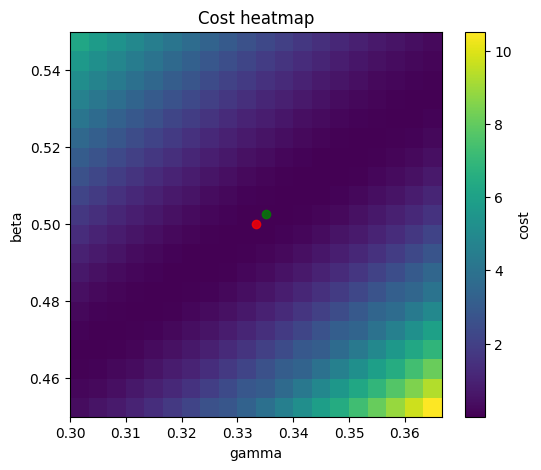

In [53]:
import matplotlib.pyplot as plt

mod = TestModelEstimate()

mod.setUp()

beta = mod.beta_true
gamma = mod.gamma_true

betas = np.linspace(beta*.9, beta*1.1, 20)
gammas = np.linspace(gamma*.9, gamma*1.1, 20)

z = np.zeros((len(betas), len(gammas)))

for i, beta in enumerate(betas):
    for j, gamma in enumerate(gammas):
        z[i, j] = mod.sir_obj.cost([beta, gamma])
        # z[i, j] = mod.sir_obj.sensitivity([beta, gamma])[0]

# plot heatmap
plt.figure(figsize=(6, 5))
plt.imshow(
    z,
    extent=[gammas.min(), gammas.max(), betas.min(), betas.max()],
    origin='lower',
    aspect='auto'
)

plt.colorbar(label="cost")
plt.xlabel("gamma")
plt.ylabel("beta")
plt.title("Cost heatmap")
plt.scatter(1/3, 0.5, color="red", alpha=0.8)

i, j = np.unravel_index(np.argmin(z), z.shape)
plt.scatter(gammas[j], betas[i], color="green", alpha=0.8)

# R0 = mod.beta_true / mod.gamma_true
# beta_preds = R0 * gammas
# plt.plot(gammas, beta_preds, color="red", linestyle="dashed")

plt.show()


In [50]:
mod.sir_obj.sensitivity([0.5, 1/3])

array([ 112.10871836, -168.01909573])

In [48]:
mod.y

array([[1.68757776e-06, 8.35161701e-07],
       [2.19555638e-06, 1.85112983e-06],
       [2.83510177e-06, 3.13024104e-06],
       [3.65924809e-06, 4.77857129e-06],
       [4.71856940e-06, 6.89727970e-06],
       [6.09458337e-06, 9.64942675e-06],
       [7.87580437e-06, 1.32120811e-05],
       [1.02127470e-05, 1.78863491e-05],
       [1.31626675e-05, 2.37867912e-05],
       [1.70621669e-05, 3.15869075e-05],
       [2.19889583e-05, 4.14422041e-05],
       [2.84724268e-05, 5.44122995e-05],
       [3.67720006e-05, 7.10164658e-05],
       [4.74186802e-05, 9.23181467e-05],
       [6.11444921e-05, 1.19783405e-04],
       [7.90145450e-05, 1.55547260e-04],
       [1.01836844e-04, 2.01229633e-04],
       [1.31334442e-04, 2.60288301e-04],
       [1.69369009e-04, 3.36463407e-04],
       [2.18271182e-04, 4.34442279e-04],
       [2.81269457e-04, 5.60728054e-04],
       [3.61516761e-04, 7.21692094e-04],
       [4.64879478e-04, 9.29195309e-04],
       [5.97973251e-04, 1.19668013e-03],
       [7.689199

In [47]:
mod.sir_obj._getSolution([mod.beta_true, mod.gamma_true])

array([[1.68757776e-06, 8.35161701e-07],
       [2.19555638e-06, 1.85112983e-06],
       [2.83510177e-06, 3.13024104e-06],
       [3.65924809e-06, 4.77857129e-06],
       [4.71856940e-06, 6.89727970e-06],
       [6.09458337e-06, 9.64942675e-06],
       [7.87580437e-06, 1.32120811e-05],
       [1.02127470e-05, 1.78863491e-05],
       [1.31626675e-05, 2.37867912e-05],
       [1.70621669e-05, 3.15869075e-05],
       [2.19889583e-05, 4.14422041e-05],
       [2.84724268e-05, 5.44122995e-05],
       [3.67720006e-05, 7.10164658e-05],
       [4.74186802e-05, 9.23181467e-05],
       [6.11444921e-05, 1.19783405e-04],
       [7.90145450e-05, 1.55547260e-04],
       [1.01836844e-04, 2.01229633e-04],
       [1.31334442e-04, 2.60288301e-04],
       [1.69369009e-04, 3.36463407e-04],
       [2.18271182e-04, 4.34442279e-04],
       [2.81269457e-04, 5.60728054e-04],
       [3.61516761e-04, 7.21692094e-04],
       [4.64879478e-04, 9.29195309e-04],
       [5.97973251e-04, 1.19668013e-03],
       [7.689199

In [55]:
res_QP = scipy.optimize.minimize(
    fun=mod.sir_obj.cost,
    # jac=mod.sir_obj.sensitivity,
    x0=mod.theta,
    method='SLSQP',
    bounds=mod.box_bounds)

res_QP

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 9.872627283701873e-11
           x: [ 5.000e-01  3.333e-01]
         nit: 7
         jac: [ 1.129e-04 -1.855e-04]
        nfev: 31
        njev: 7
 multipliers: []